In [68]:
!pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo

Required Libraries

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

plt.style.use('ggplot')
sns.set_theme()

%matplotlib inline

In [70]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Dataset Overview

In [71]:
df.info()

df.describe()

print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [72]:
heart_disease.metadata

{'uci_id': 45,
 'name': 'Heart Disease',
 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease',
 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv',
 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach',
 'area': 'Health and Medicine',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 303,
 'num_features': 13,
 'feature_types': ['Categorical', 'Integer', 'Real'],
 'demographics': ['Age', 'Sex'],
 'target_col': ['num'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1989,
 'last_updated': 'Fri Nov 03 2023',
 'dataset_doi': '10.24432/C52P4X',
 'creators': ['Andras Janosi',
  'William Steinbrunn',
  'Matthias Pfisterer',
  'Robert Detrano'],
 'intro_paper': {'ID': 231,
  'type': 'NATIVE',
  'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.',
  'authors': 'R. Detr

Missing Value Analysis

In [73]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
...,...
oldpeak,0
slope,0
ca,4
thal,2


Duplicate Check

In [74]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [75]:
df.drop_duplicates(inplace=True)

print(df.shape)

(303, 14)


Data Preprocessing

Convert the target into binary

In [46]:
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

df["num"].value_counts()

,count
num,
0,164
1,139


Handle Missing Values

In [76]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
...,...
oldpeak,0
slope,0
ca,0
thal,0


Exploratory Data Analysis

Heart Disease Distribution

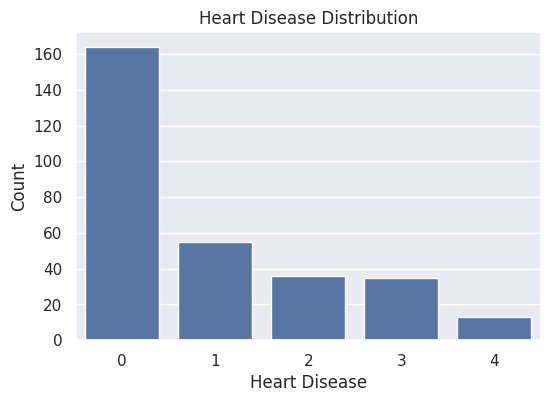

In [77]:
plt.figure(figsize=(6,4))

sns.countplot(x="num", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

Age Distribution

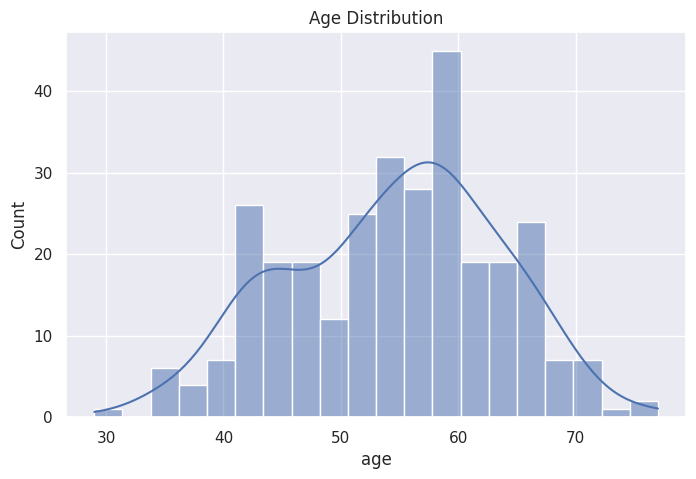

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

Gender Distribution

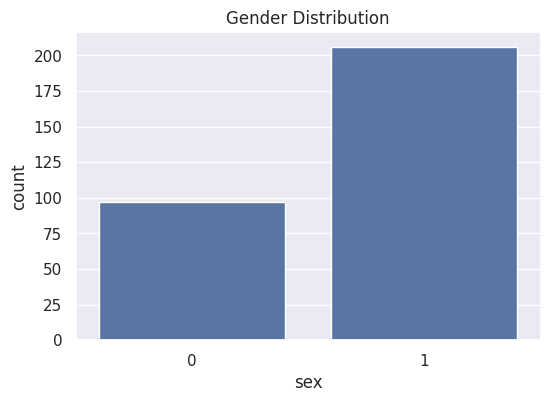

In [80]:
plt.figure(figsize=(6,4))

sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")

plt.show()

Chest Pain Type

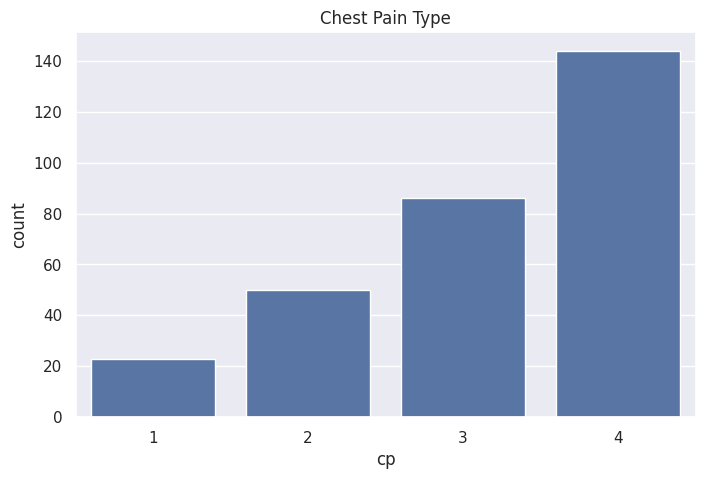

In [82]:
plt.figure(figsize=(8,5))

sns.countplot(x="cp", data=df)

plt.title("Chest Pain Type")

plt.show()

Heart Disease by Gender

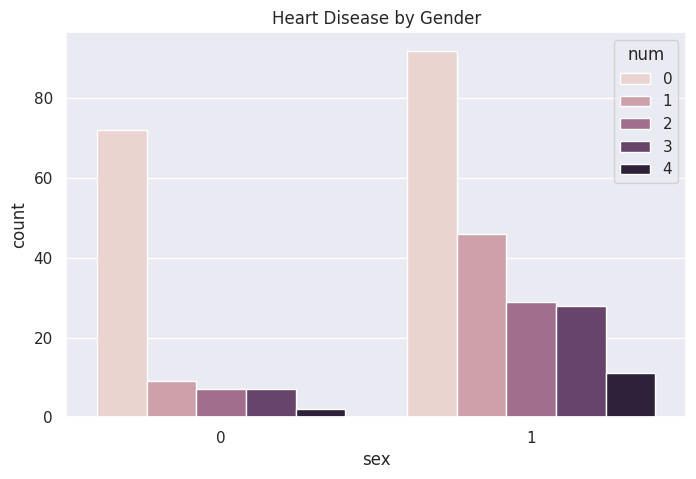

In [83]:
plt.figure(figsize=(8,5))

sns.countplot(x="sex", hue="num", data=df)

plt.title("Heart Disease by Gender")

plt.show()

Cholesterol Distribution

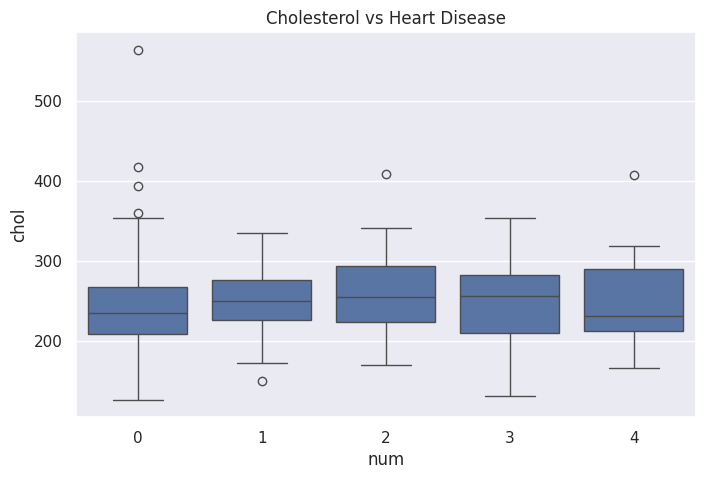

In [84]:
plt.figure(figsize=(8,5))

sns.boxplot(x="num", y="chol", data=df)

plt.title("Cholesterol vs Heart Disease")

plt.show()

Resting Blood Pressure

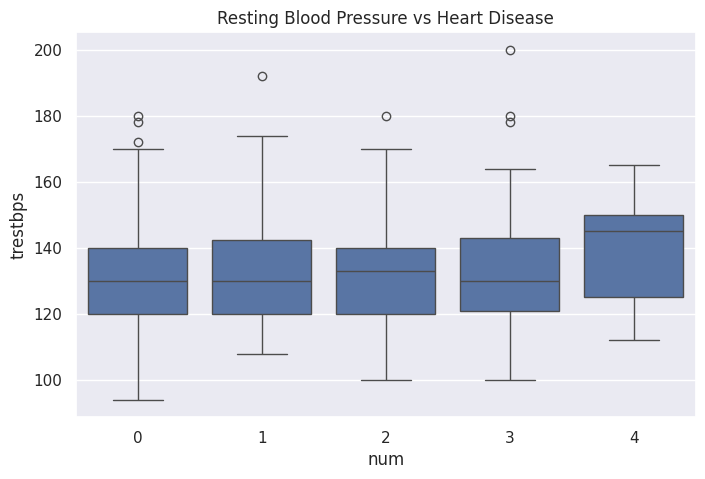

In [85]:
plt.figure(figsize=(8,5))

sns.boxplot(x="num", y="trestbps", data=df)

plt.title("Resting Blood Pressure vs Heart Disease")

plt.show()

Maximum Heart Rate

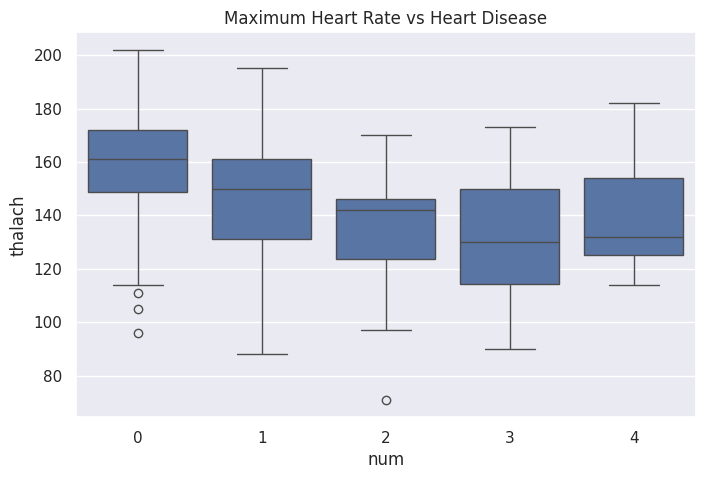

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(x="num", y="thalach", data=df)

plt.title("Maximum Heart Rate vs Heart Disease")

plt.show()

Correlation Heatmap

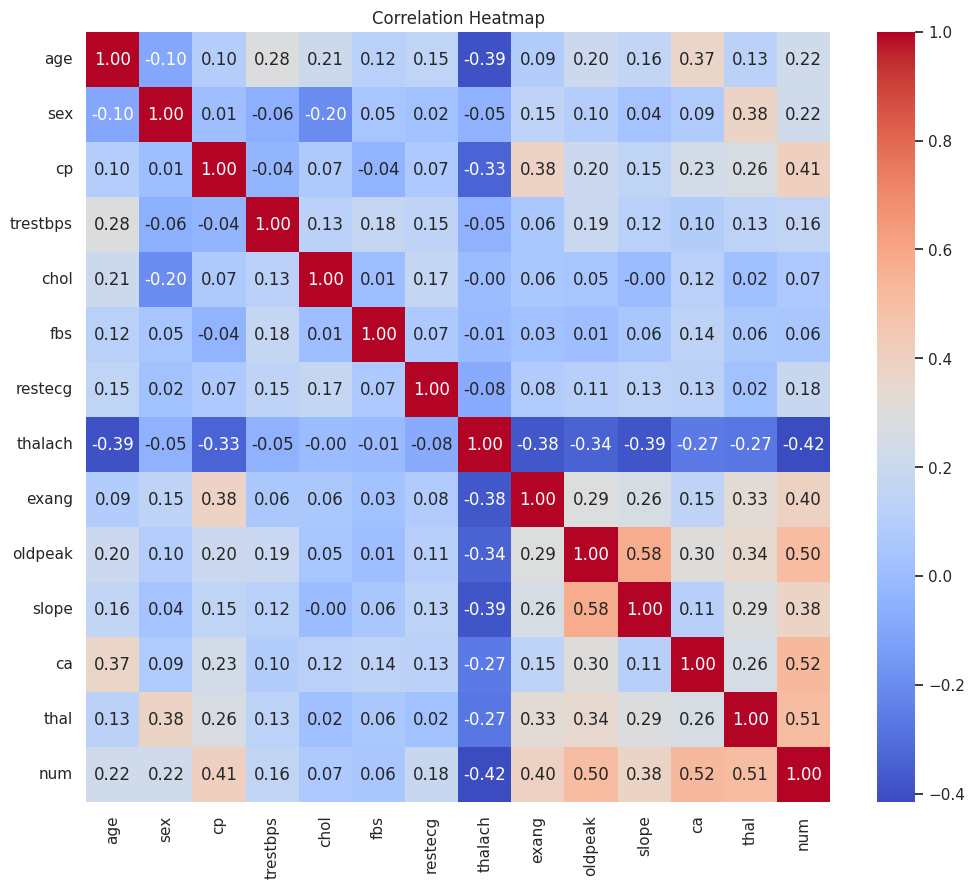

In [87]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Pairplot

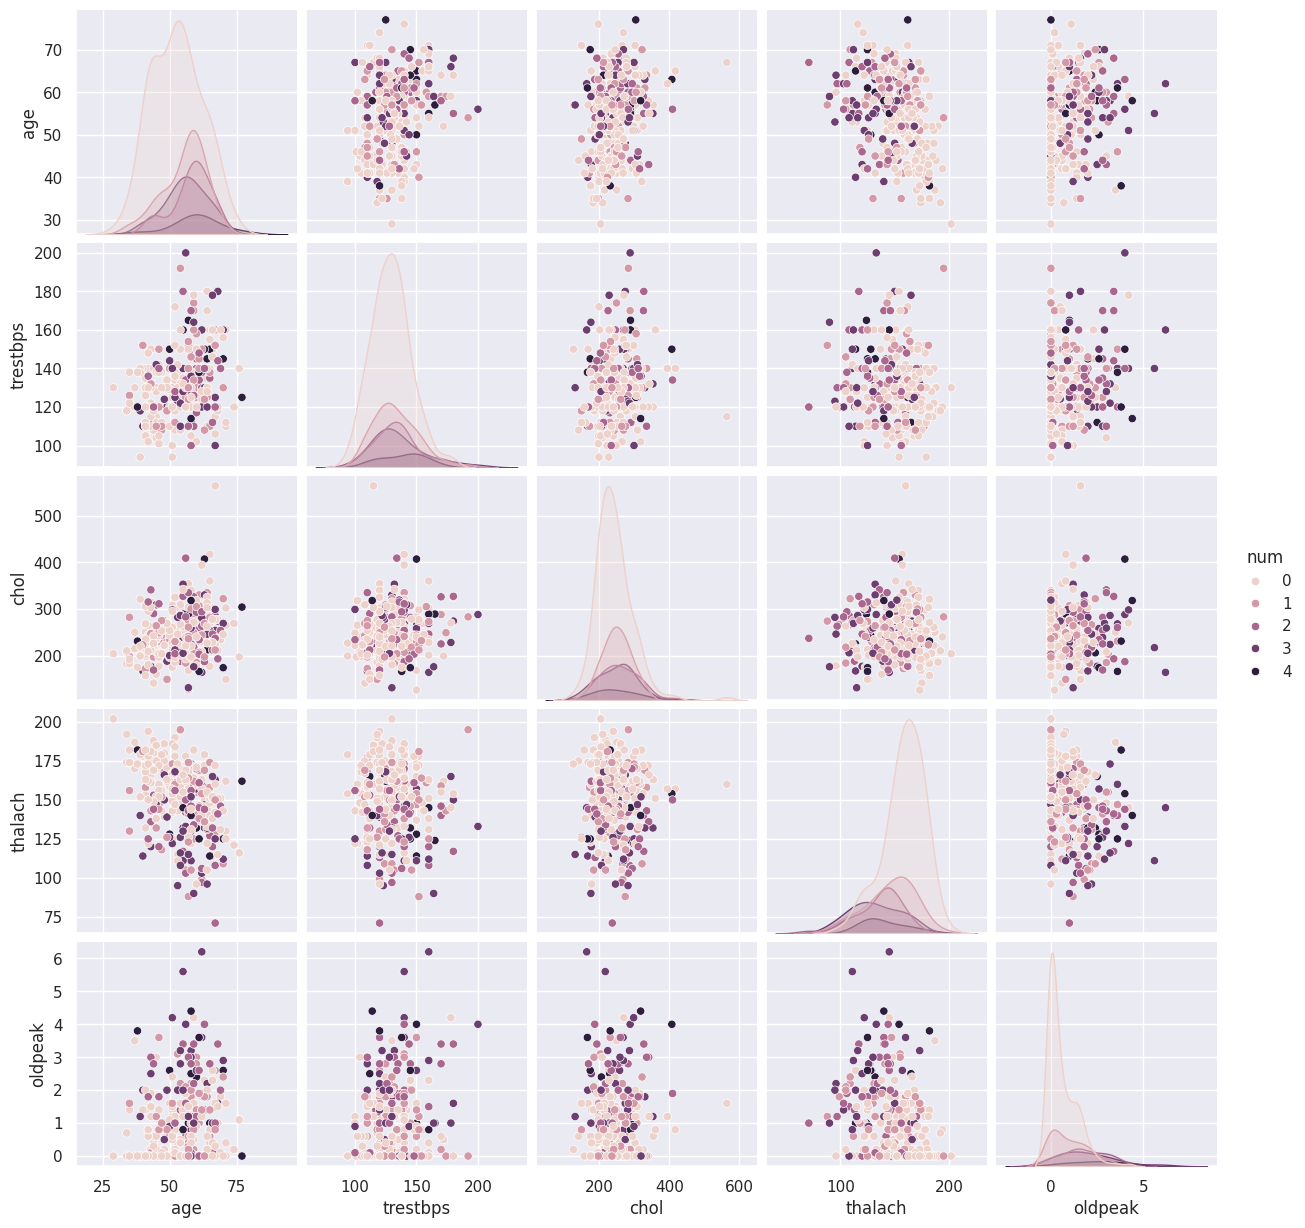

In [88]:
sns.pairplot(
    df[["age","trestbps","chol","thalach","oldpeak","num"]],
    hue="num"
)

plt.show()

Prepare Features and Target

In [89]:
X = df.drop("num", axis=1)

y = df["num"]

Train-Test Split

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Feature Scaling

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Logistic Regression

In [92]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Logistic Regression Accuracy

In [93]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.6065573770491803


Classification Report

In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        33
           1       0.36      0.36      0.36        11
           2       0.20      0.14      0.17         7
           3       0.43      0.43      0.43         7
           4       0.00      0.00      0.00         3

    accuracy                           0.61        61
   macro avg       0.36      0.36      0.36        61
weighted avg       0.56      0.61      0.58        61



Confusion Matrix

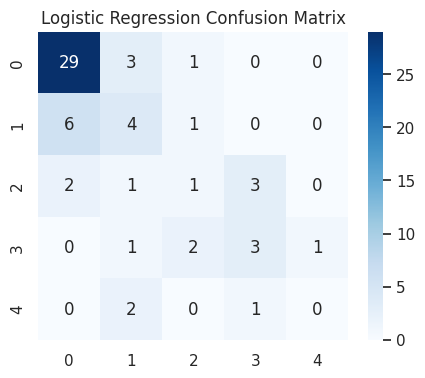

In [95]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

Random Forest

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Random Forest Accuracy

In [97]:
print("Random Forest Accuracy:")

print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.5245901639344263


Random Forest Classification Report

In [98]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.78      0.97      0.86        33
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3

    accuracy                           0.52        61
   macro avg       0.16      0.19      0.17        61
weighted avg       0.42      0.52      0.47        61



Random Forest Confusion Matrix

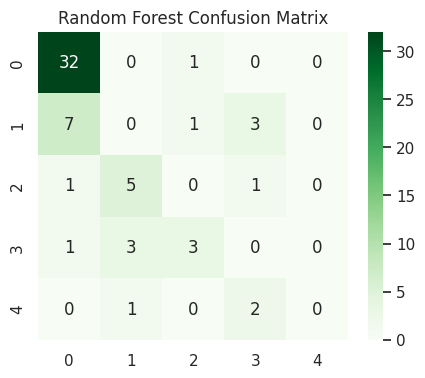

In [99]:
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

Feature Importance

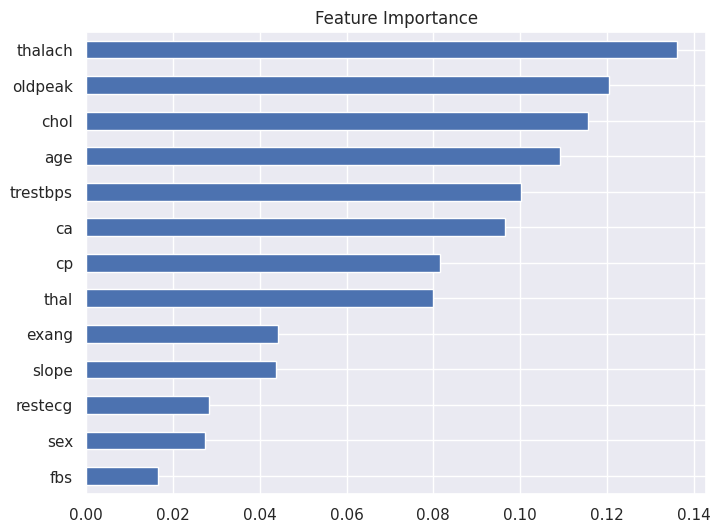

In [100]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,6))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.show()

Model Comparison

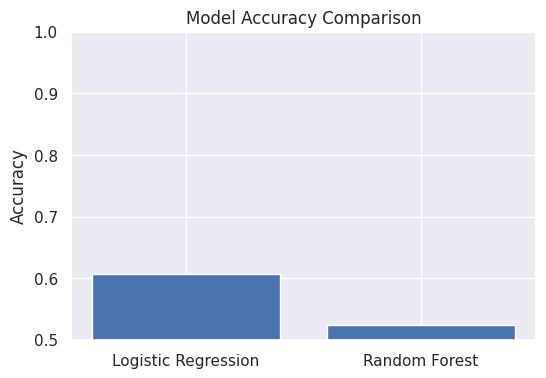

In [102]:
models = ["Logistic Regression", "Random Forest"]

scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.ylim(0.5,1)

plt.title("Model Accuracy Comparison")

plt.show()

Prediction

In [104]:
sample = X_test[0].reshape(1, -1)

prediction = lr.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Prediction: 0
No Heart Disease
